In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
df = pd.read_csv("compressed_data.csv")

C:\Users\Nandini\AppData\Local\Temp\ipykernel_11956\1184112827.py:1: DtypeWarning: Columns (0: license) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv("compressed_data.csv")


In [5]:
df.head()


,id,NAME,host id,host_identity_verified,host name,neighbourhood group,neighbourhood,lat,long,country,...,service fee,minimum nights,number of reviews,last review,reviews per month,review rate number,calculated host listings count,availability 365,house_rules,license
0,1001254,Clean & quiet apt home by the park,80014485718,unconfirmed,Madaline,Brooklyn,Kensington,40.64749,-73.97237,United States,...,$193,10.0,9.0,10/19/2021,0.21,4.0,6.0,286.0,Clean up and treat the home the way you'd like...,NaN
1,1002102,Skylit Midtown Castle,52335172823,verified,Jenna,Manhattan,Midtown,40.75362,-73.98377,United States,...,$28,30.0,45.0,5/21/2022,0.38,4.0,2.0,228.0,Pet friendly but please confirm with me if the...,NaN
2,1002403,THE VILLAGE OF HARLEM....NEW YORK !,78829239556,NaN,Elise,Manhattan,Harlem,40.80902,-73.94190,United States,...,$124,3.0,0.0,NaN,NaN,5.0,1.0,352.0,"I encourage you to use my kitchen, cooking and...",NaN
3,1002755,NaN,85098326012,unconfirmed,Garry,Brooklyn,Clinton Hill,40.68514,-73.95976,United States,...,$74,30.0,270.0,7/5/2019,4.64,4.0,1.0,322.0,NaN,NaN
4,1003689,Entire Apt: Spacious Studio/Loft by central park,92037596077,verified,Lyndon,Manhattan,East Harlem,40.79851,-73.94399,United States,...,$41,10.0,9.0,11/19/2018,0.10,3.0,1.0,289.0,"Please no smoking in the house, porch or on th...",NaN


In [6]:
df.columns

Index(['id', 'NAME', 'host id', 'host_identity_verified', 'host name',
       'neighbourhood group', 'neighbourhood', 'lat', 'long', 'country',
       'country code', 'instant_bookable', 'cancellation_policy', 'room type',
       'Construction year', 'price', 'service fee', 'minimum nights',
       'number of reviews', 'last review', 'reviews per month',
       'review rate number', 'calculated host listings count',
       'availability 365', 'house_rules', 'license'],
      dtype='str')

# Checking missing values

In [7]:
print(df.isnull().sum())

id                                    0
NAME                                220
host id                               0
host_identity_verified              244
host name                           354
neighbourhood group                  29
neighbourhood                        16
lat                                   8
long                                  8
country                             360
country code                         96
instant_bookable                     96
cancellation_policy                  67
room type                             1
Construction year                   191
price                               217
service fee                         242
minimum nights                      382
number of reviews                   170
last review                       12966
reviews per month                 12952
review rate number                  268
calculated host listings count      168
availability 365                    439
house_rules                       45713


In [8]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 83619 entries, 0 to 83618
Data columns (total 26 columns):
 #   Column                          Non-Null Count  Dtype  
---  ------                          --------------  -----  
 0   id                              83619 non-null  int64  
 1   NAME                            83399 non-null  str    
 2   host id                         83619 non-null  int64  
 3   host_identity_verified          83375 non-null  str    
 4   host name                       83265 non-null  str    
 5   neighbourhood group             83590 non-null  str    
 6   neighbourhood                   83603 non-null  str    
 7   lat                             83611 non-null  float64
 8   long                            83611 non-null  float64
 9   country                         83259 non-null  str    
 10  country code                    83523 non-null  str    
 11  instant_bookable                83523 non-null  object 
 12  cancellation_policy             83552 non-n

# Handling Missing Values

In [9]:
df['last review'] = pd.to_datetime(df['last review'], errors ='coerce')

In [11]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 83619 entries, 0 to 83618
Data columns (total 26 columns):
 #   Column                          Non-Null Count  Dtype         
---  ------                          --------------  -----         
 0   id                              83619 non-null  int64         
 1   NAME                            83399 non-null  str           
 2   host id                         83619 non-null  int64         
 3   host_identity_verified          83375 non-null  str           
 4   host name                       83265 non-null  str           
 5   neighbourhood group             83590 non-null  str           
 6   neighbourhood                   83603 non-null  str           
 7   lat                             83611 non-null  float64       
 8   long                            83611 non-null  float64       
 9   country                         83259 non-null  str           
 10  country code                    83523 non-null  str           
 11  instant_booka

In [14]:
df.fillna({'reviews per month' : 0 , 'last review' : df['last review'].min()},inplace =True)

,id,NAME,host id,host_identity_verified,host name,neighbourhood group,neighbourhood,lat,long,country,...,service fee,minimum nights,number of reviews,last review,reviews per month,review rate number,calculated host listings count,availability 365,house_rules,license
0,1001254,Clean & quiet apt home by the park,80014485718,unconfirmed,Madaline,Brooklyn,Kensington,40.64749,-73.97237,United States,...,$193,10.0,9.0,2021-10-19,0.21,4.0,6.0,286.0,Clean up and treat the home the way you'd like...,NaN
1,1002102,Skylit Midtown Castle,52335172823,verified,Jenna,Manhattan,Midtown,40.75362,-73.98377,United States,...,$28,30.0,45.0,2022-05-21,0.38,4.0,2.0,228.0,Pet friendly but please confirm with me if the...,NaN
2,1002403,THE VILLAGE OF HARLEM....NEW YORK !,78829239556,NaN,Elise,Manhattan,Harlem,40.80902,-73.94190,United States,...,$124,3.0,0.0,2012-07-11,0.00,5.0,1.0,352.0,"I encourage you to use my kitchen, cooking and...",NaN
3,1002755,NaN,85098326012,unconfirmed,Garry,Brooklyn,Clinton Hill,40.68514,-73.95976,United States,...,$74,30.0,270.0,2019-07-05,4.64,4.0,1.0,322.0,NaN,NaN
4,1003689,Entire Apt: Spacious Studio/Loft by central park,92037596077,verified,Lyndon,Manhattan,East Harlem,40.79851,-73.94399,United States,...,$41,10.0,9.0,2018-11-19,0.10,3.0,1.0,289.0,"Please no smoking in the house, porch or on th...",NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
83614,47181348,Cozy room in spacious and sunny apartment,49191275331,verified,Angela,Queens,Ridgewood,40.69787,-73.90008,United States,...,$166,2.0,4.0,2019-05-31,0.19,4.0,1.0,175.0,"Access to kitchen appliances and cutlery, etc....",NaN
83615,47181901,Ashes Cove,71224224211,unconfirmed,Aston,Queens,Springfield Gardens,40.66013,-73.77166,United States,...,$147,3.0,23.0,2019-06-02,1.18,2.0,2.0,357.0,Please treat our home as if it were your own.,NaN
83616,47182453,Lavish 3 bedroom near Penn Station / MSG,81547119719,unconfirmed,Michael,Manhattan,Chelsea,40.74881,-73.99375,United States,...,$150,2.0,42.0,2019-07-01,1.99,4.0,1.0,36.0,You are my guest - please behave as such! Thi...,NaN
83617,47183005,Chez Jazzy Midtown East,9831488219,verified,Chez,Manhattan,Midtown,40.75614,-73.96706,United States,...,$109,5.0,30.0,2018-10-31,1.40,2.0,1.0,0.0,We expect our guests to behave in a respectful...,NaN


In [19]:
df.dropna(subset =['NAME', 'host name'], inplace= True)

In [20]:
print(df.isnull().sum())

id                                    0
NAME                                  0
host id                               0
host_identity_verified              231
host name                             0
neighbourhood group                  26
neighbourhood                        16
lat                                   8
long                                  8
country                             354
country code                         87
instant_bookable                     87
cancellation_policy                  61
room type                             1
Construction year                   177
price                               214
service fee                         242
minimum nights                      376
number of reviews                   169
last review                           0
reviews per month                     0
review rate number                  256
calculated host listings count      167
availability 365                    411
house_rules                       45482


In [21]:
df = df.drop(columns=['license','house_rules'], errors = 'ignore')

In [22]:
df.head()

,id,NAME,host id,host_identity_verified,host name,neighbourhood group,neighbourhood,lat,long,country,...,Construction year,price,service fee,minimum nights,number of reviews,last review,reviews per month,review rate number,calculated host listings count,availability 365
0,1001254,Clean & quiet apt home by the park,80014485718,unconfirmed,Madaline,Brooklyn,Kensington,40.64749,-73.97237,United States,...,2020.0,$966,$193,10.0,9.0,2021-10-19,0.21,4.0,6.0,286.0
1,1002102,Skylit Midtown Castle,52335172823,verified,Jenna,Manhattan,Midtown,40.75362,-73.98377,United States,...,2007.0,$142,$28,30.0,45.0,2022-05-21,0.38,4.0,2.0,228.0
2,1002403,THE VILLAGE OF HARLEM....NEW YORK !,78829239556,NaN,Elise,Manhattan,Harlem,40.80902,-73.94190,United States,...,2005.0,$620,$124,3.0,0.0,2012-07-11,0.00,5.0,1.0,352.0
4,1003689,Entire Apt: Spacious Studio/Loft by central park,92037596077,verified,Lyndon,Manhattan,East Harlem,40.79851,-73.94399,United States,...,2009.0,$204,$41,10.0,9.0,2018-11-19,0.10,3.0,1.0,289.0
5,1004098,Large Cozy 1 BR Apartment In Midtown East,45498551794,verified,Michelle,Manhattan,Murray Hill,40.74767,-73.97500,United States,...,2013.0,$577,$115,3.0,74.0,2019-06-22,0.59,3.0,1.0,374.0


In [25]:
# Remove dollar signs and convert to float
df['price'] = df['price'].replace('[\$,]','',regex = True).astype(float)
df['service fee'] = df['service fee'].replace('[\$,]', '', regex = True).astype(float)

In [26]:
df.head()

,id,NAME,host id,host_identity_verified,host name,neighbourhood group,neighbourhood,lat,long,country,...,Construction year,price,service fee,minimum nights,number of reviews,last review,reviews per month,review rate number,calculated host listings count,availability 365
0,1001254,Clean & quiet apt home by the park,80014485718,unconfirmed,Madaline,Brooklyn,Kensington,40.64749,-73.97237,United States,...,2020.0,966.0,193.0,10.0,9.0,2021-10-19,0.21,4.0,6.0,286.0
1,1002102,Skylit Midtown Castle,52335172823,verified,Jenna,Manhattan,Midtown,40.75362,-73.98377,United States,...,2007.0,142.0,28.0,30.0,45.0,2022-05-21,0.38,4.0,2.0,228.0
2,1002403,THE VILLAGE OF HARLEM....NEW YORK !,78829239556,NaN,Elise,Manhattan,Harlem,40.80902,-73.94190,United States,...,2005.0,620.0,124.0,3.0,0.0,2012-07-11,0.00,5.0,1.0,352.0
4,1003689,Entire Apt: Spacious Studio/Loft by central park,92037596077,verified,Lyndon,Manhattan,East Harlem,40.79851,-73.94399,United States,...,2009.0,204.0,41.0,10.0,9.0,2018-11-19,0.10,3.0,1.0,289.0
5,1004098,Large Cozy 1 BR Apartment In Midtown East,45498551794,verified,Michelle,Manhattan,Murray Hill,40.74767,-73.97500,United States,...,2013.0,577.0,115.0,3.0,74.0,2019-06-22,0.59,3.0,1.0,374.0


# Remove Duplicates

In [27]:
df.drop_duplicates(inplace = True)

In [28]:
df.info()

<class 'pandas.DataFrame'>
Index: 83051 entries, 0 to 83618
Data columns (total 24 columns):
 #   Column                          Non-Null Count  Dtype         
---  ------                          --------------  -----         
 0   id                              83051 non-null  int64         
 1   NAME                            83051 non-null  str           
 2   host id                         83051 non-null  int64         
 3   host_identity_verified          82820 non-null  str           
 4   host name                       83051 non-null  str           
 5   neighbourhood group             83025 non-null  str           
 6   neighbourhood                   83035 non-null  str           
 7   lat                             83043 non-null  float64       
 8   long                            83043 non-null  float64       
 9   country                         82697 non-null  str           
 10  country code                    82964 non-null  str           
 11  instant_bookable  

# Descriptive Statistics

In [29]:
df.describe()

,id,host id,lat,long,Construction year,price,service fee,minimum nights,number of reviews,last review,reviews per month,review rate number,calculated host listings count,availability 365
count,8.305100e+04,8.305100e+04,83043.000000,83043.000000,82874.000000,82837.000000,82809.000000,82675.000000,82882.000000,83051,83051.000000,82795.000000,82884.000000,82640.000000
mean,2.411029e+07,4.925027e+10,40.728093,-73.949512,2012.487053,625.055446,124.972334,8.381155,28.303661,2018-06-25 11:55:01.946996,1.168250,3.293605,8.603024,145.923451
min,1.001254e+06,1.244726e+08,40.499790,-74.249840,2003.000000,50.000000,10.000000,-1223.000000,0.000000,2012-07-11 00:00:00,0.000000,1.000000,1.000000,-10.000000
25%,1.252922e+07,2.441698e+10,40.688630,-73.982700,2007.000000,339.000000,68.000000,2.000000,1.000000,2017-08-13 00:00:00,0.090000,2.000000,1.000000,7.000000
50%,2.413332e+07,4.915530e+10,40.722410,-73.954480,2012.000000,625.000000,125.000000,3.000000,7.000000,2019-05-31 00:00:00,0.490000,3.000000,1.000000,109.000000
75%,3.565402e+07,7.405476e+10,40.762715,-73.932060,2017.000000,912.000000,182.000000,5.000000,31.000000,2019-07-05 00:00:00,1.720000,4.000000,2.000000,275.000000
max,4.718356e+07,9.876313e+10,40.916970,-73.000000,2022.000000,1200.000000,240.000000,5645.000000,1024.000000,2058-06-16 00:00:00,90.000000,5.000000,332.000000,3677.000000
std,1.332745e+07,2.858347e+10,0.055830,0.049920,5.764876,331.733573,66.339604,32.434041,51.682218,NaN,1.707576,1.276476,34.838998,135.632486


# Visualization

# What is the distribution of listing price ?

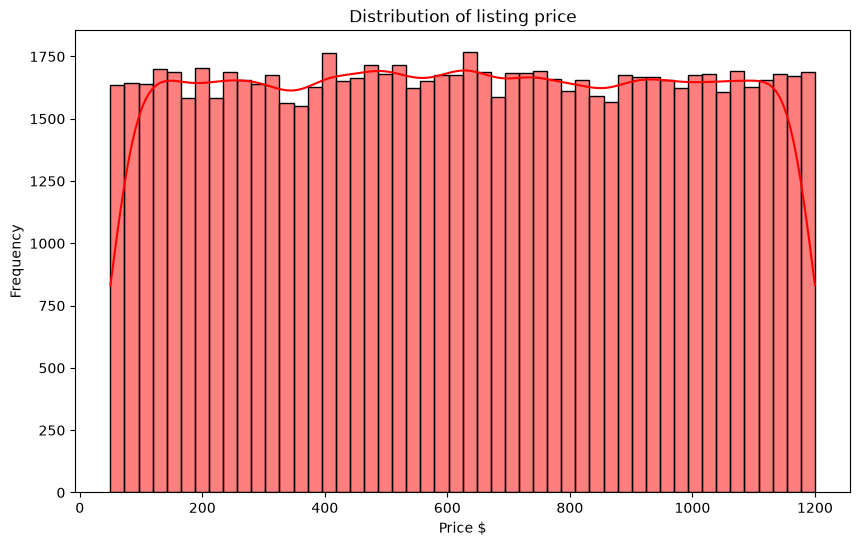

In [34]:
plt.figure(figsize =(10,6))
sns.histplot(df['price'], bins = 50 , kde = True , color = 'red')
plt.title("Distribution of listing price")
plt.xlabel("Price $")
plt.ylabel("Frequency")
plt.show()

In [ ]:
The histogram shows a fairly even distribution of
listing prices across different price ranges , indicating no
particular concentration of listings in any specific price range.
The KDE line helps visualize this even more spread more clearly ,
confirming that the dataset contains listings with a wide variety of price.

# How are different room types distributed ?

In [35]:
df['room type']

0           Private room
1        Entire home/apt
2           Private room
4        Entire home/apt
5        Entire home/apt
              ...       
83614       Private room
83615    Entire home/apt
83616    Entire home/apt
83617    Entire home/apt
83618                NaN
Name: room type, Length: 83051, dtype: str

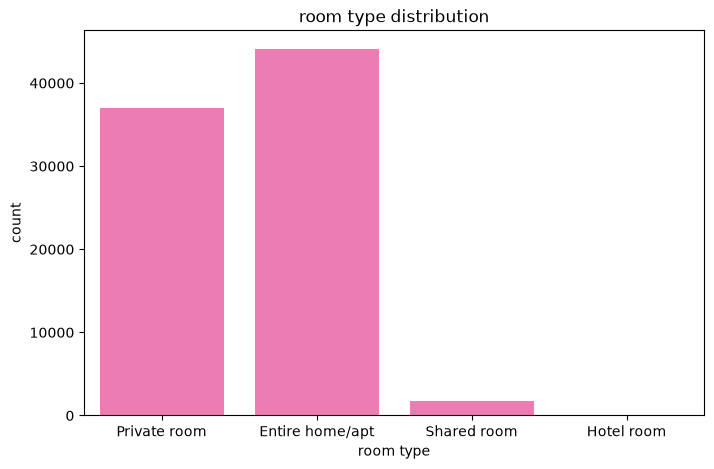

In [41]:
plt.figure(figsize = (8,5))
sns.countplot( x = 'room type', data = df, color ='hotpink')
plt.title("room type distribution")
plt.xlabel("room type")
plt.ylabel("count")
plt.show()

# How are listings distributed across different neighborhoods ?

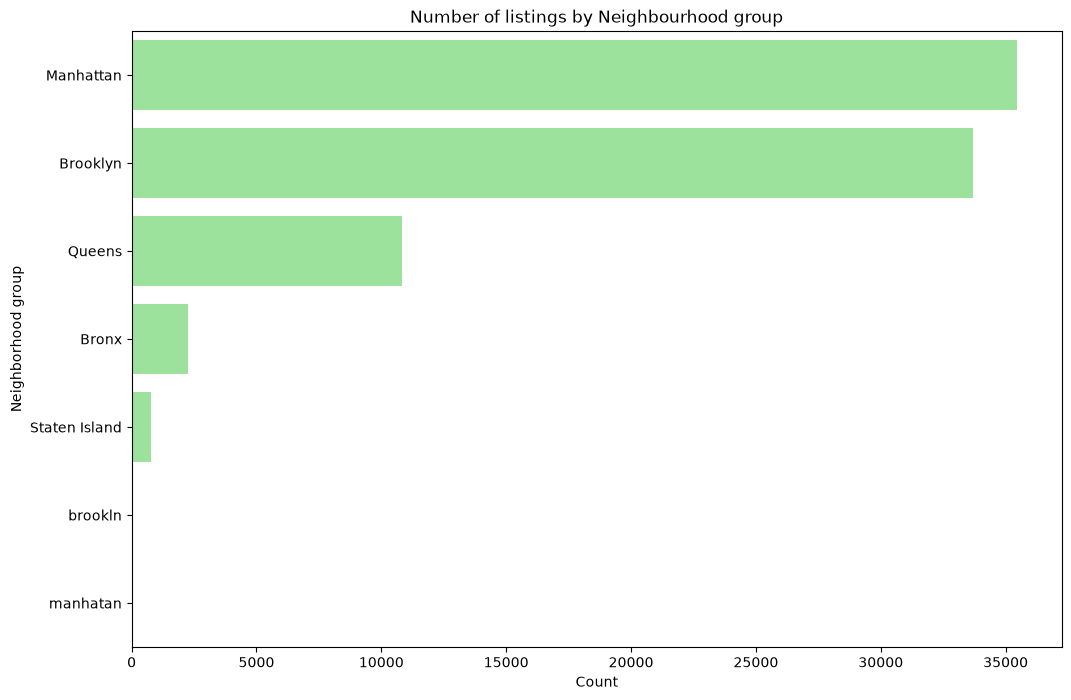

In [45]:
plt.figure(figsize =(12,8))
sns.countplot( y= "neighbourhood group", data = df, color ="lightgreen" , order =df["neighbourhood group"].value_counts().index)
plt.title("Number of listings by Neighbourhood group")
plt.xlabel('Count')
plt.ylabel('Neighborhood group')
plt.show()

# What is the relationship between price and room type ?

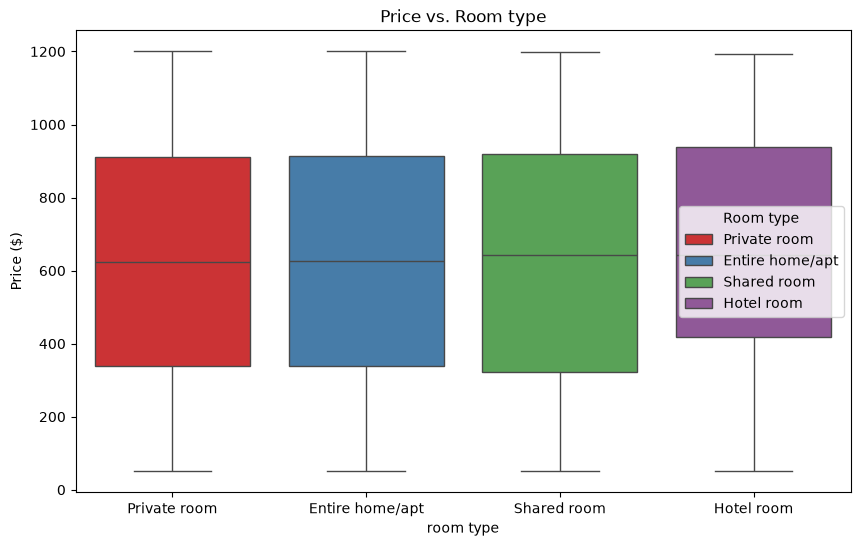

In [47]:
plt.figure(figsize=(10,6))
sns.boxplot( x= "room type", y ="price", hue ="room type", data =df , palette ='Set1')
plt.title("Price vs. Room type")
plt.xlabel("room type")
plt.ylabel("Price ($)")
plt.legend(title = "Room type")
plt.show()


# How has the number of reviews changed over time ?

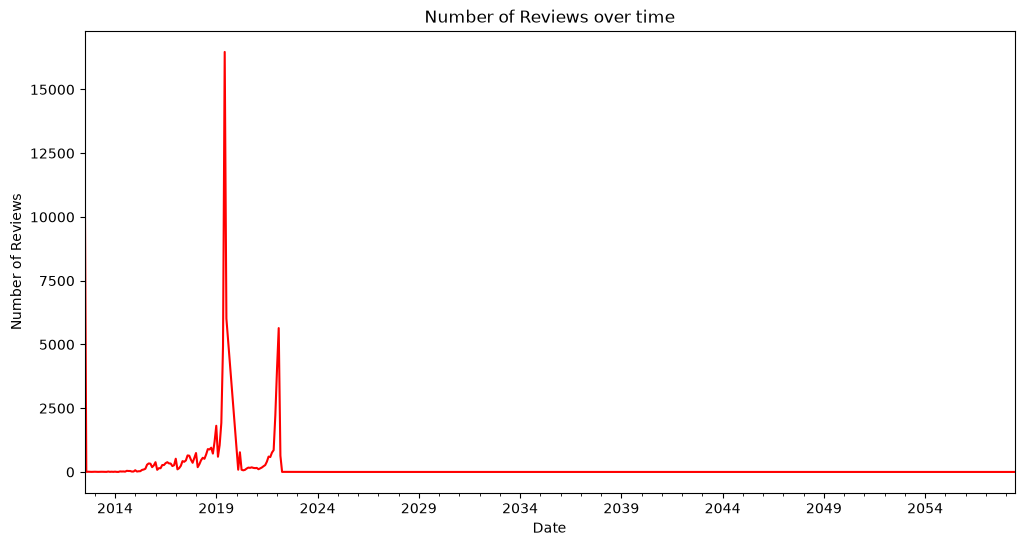

In [49]:
df["last review"] = pd.to_datetime(df["last review"])
reviews_over_time = df.groupby(df["last review"].dt.to_period('M')).size()

plt.figure(figsize =(12,6))
reviews_over_time.plot(kind ='line',color ='red')
plt.title("Number of Reviews over time")
plt.xlabel("Date")
plt.ylabel("Number of Reviews")
plt.show()

